# Append Sep 1 00:00 to the hourly ERA5 raw files

One-off notebook. Appends the Sep 1 00:00 hour of each year (2000–2020) to one hourly ERA5 raw file, so the last 3-hourly window of each season (Aug 31 21:00) has the snapshot and the 23:00–24:00 accumulation it needs.

Run one variable at a time: set `VARNAME`, restart the kernel, and run top to bottom. The existing file is opened lazily with dask in one-season time chunks, so `t` and `q` (tens of GB) never sit in memory at once; peak memory is roughly `NWORKERS` × one season of the variable (about 1.6 GB per season for `t` and `q`). The arrays can still be displayed and inspected; checks and plots read only what they need. Nothing is written until the final cell. The original file is kept as `<name>_old.nc`; the new file takes the current name.

Variables to process: `t`, `q`, `ps`, `shf`, `lhf`, `tp`. IMERG and the static fields are not affected.

In [40]:
import os
import re
import sys
import dask
import warnings
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from datetime import datetime
from IPython.display import display
from dask.diagnostics import ProgressBar
sys.path.insert(0,'..')
from scripts.utils import Config
from scripts.data.classes import DataDownloader
warnings.filterwarnings('ignore')

In [49]:
CONFIG    = Config()
VARNAME   = 'tp'
VARIABLES = {
    't':(lambda era5:era5.temperature,'ERA5 air temperature','K'),
    'q':(lambda era5:era5.specific_humidity,'ERA5 specific humidity','kg/kg'),
    'ps':(lambda era5:era5.surface_pressure/100.0,'ERA5 surface pressure','hPa'),
    'lhf':(lambda era5:-era5.mean_surface_latent_heat_flux,'ERA5 mean surface latent heat flux','W/m²'),
    'shf':(lambda era5:-era5.mean_surface_sensible_heat_flux,'ERA5 mean surface sensible heat flux','W/m²'),
    'tp':(lambda era5:era5.total_precipitation*1000,'ERA5 total accumulated precipitation','mm')}
GETTER,LONGNAME,UNITS = VARIABLES[VARNAME]
RADIUS     = 4
YEARS      = CONFIG.years
NEWTIMES   = pd.DatetimeIndex([f'{year}-09-01 00:00' for year in YEARS])
LASTTIMES  = NEWTIMES-pd.Timedelta(hours=1)
FILENAME   = re.sub(r'\s+','_',LONGNAME)
FILEPATH   = os.path.join(CONFIG.rawdir,f'{FILENAME}.nc')
BACKUPPATH = os.path.join(CONFIG.rawdir,f'{FILENAME}_old.nc')
TEMPPATH   = os.path.join(CONFIG.rawdir,f'{FILENAME}_new.nc')
TIMECHUNKSIZE = 2208
NWORKERS   = 4
PLOTYEAR   = 2018
dask.config.set(scheduler='threads',num_workers=NWORKERS)
print(f'Variable: {VARNAME} ({LONGNAME}, {UNITS})')
print(f'File:     {FILEPATH}')
print(f'Backup:   {BACKUPPATH}')

Variable: tp (ERA5 total accumulated precipitation, mm)
File:     /global/cfs/cdirs/m4334/sferrett/monsoon-discovery/data/raw/ERA5_total_accumulated_precipitation.nc
Backup:   /global/cfs/cdirs/m4334/sferrett/monsoon-discovery/data/raw/ERA5_total_accumulated_precipitation_old.nc


In [50]:
def check_contiguous(times,end):
    '''
    Purpose: List years whose timestamps are not exactly hourly from Jun 1 00:00 to the given end.
    Args:
    - times (pd.DatetimeIndex): timestamps
    - end (str): last expected timestamp of each year as 'MM-DD HH:MM'
    Returns:
    - list[int]: years that do not match
    '''
    bad = []
    for year in YEARS:
        actual   = times[times.year==year]
        expected = pd.date_range(f'{year}-06-01 00:00',f'{year}-{end}',freq='1h')
        if len(actual)!=len(expected) or not (actual==expected).all():
            bad.append(year)
    return bad

def download_hours():
    '''
    Purpose: Download Sep 1 00:00 of every year for VARNAME and process it exactly as scripts/data/download.py
        does (standardize, subset with the same radius, wrap with metadata). The downloader is given months=[9]
        so its time subset keeps the selected hours.
    Returns:
    - xr.Dataset: Dataset with the 21 new hours
    '''
    downloader = DataDownloader(
        author=CONFIG.author,
        email=CONFIG.email,
        savedir=CONFIG.rawdir,
        latrange=CONFIG.latrange,
        lonrange=CONFIG.lonrange,
        levrange=CONFIG.levrange,
        years=YEARS,
        months=[9])
    era5 = downloader.retrieve_era5()
    da   = GETTER(era5).sel(time=NEWTIMES)
    return downloader.process(da,VARNAME,LONGNAME,UNITS,radius=RADIUS).load()

def domain_stats(da,times):
    '''
    Purpose: Domain minimum, mean, and maximum at each timestamp.
    Args:
    - da (xr.DataArray): field with a time dimension
    - times (pd.DatetimeIndex): timestamps to summarize
    Returns:
    - pd.DataFrame: one row per timestamp
    '''
    sub  = da.sel(time=times)
    dims = [dim for dim in sub.dims if dim!='time']
    return pd.DataFrame({'min':sub.min(dims).values,'mean':sub.mean(dims).values,'max':sub.max(dims).values},index=times)

## 1. Load the existing file

In [51]:
old = xr.open_dataset(FILEPATH,engine='h5netcdf',chunks={'time':TIMECHUNKSIZE})
display(old)
oldtimes = pd.DatetimeIndex(old.time.values)
print(f'{len(oldtimes)} timestamps, {oldtimes[0]} → {oldtimes[-1]}, dtype {old[VARNAME].dtype}')
print(f'Already contains any Sep 1 00:00: {bool(oldtimes.isin(NEWTIMES).any())}')
print(f'Years not hourly Jun 1 00:00 → Aug 31 23:00: {check_contiguous(oldtimes,"08-31 23:00")}')

<xarray.Dataset>
Dimensions:  (lat: 89, lon: 129, time: 46368)
Coordinates:
  * lat      (lat) float32 4.0 4.25 4.5 4.75 5.0 ... 25.0 25.25 25.5 25.75 26.0
  * lon      (lon) float32 59.0 59.25 59.5 59.75 60.0 ... 90.25 90.5 90.75 91.0
  * time     (time) datetime64[ns] 2000-06-01 ... 2020-08-31T23:00:00
Data variables:
    tp       (lat, lon, time) float32 dask.array<chunksize=(89, 129, 2208), meta=np.ndarray>
Attributes:
    history:  Created on 2026-03-05 by Savannah L. Ferretti (savannah.ferrett...

46368 timestamps, 2000-06-01 00:00:00 → 2020-08-31 23:00:00, dtype float32
Already contains any Sep 1 00:00: False
Years not hourly Jun 1 00:00 → Aug 31 23:00: []


## 2. Download the 21 new hours

In [52]:
new = download_hours()
new[VARNAME] = new[VARNAME].astype(old[VARNAME].dtype)
display(new)
newtimes = pd.DatetimeIndex(new.time.values)
print(f'Timestamps match Sep 1 00:00 of each year: {len(newtimes)==len(NEWTIMES) and bool((newtimes==NEWTIMES).all())}')
print(f'Non-finite values: {int((~np.isfinite(new[VARNAME].values)).sum())}')
for dim in new[VARNAME].dims:
    if dim!='time':
        print(f'`{dim}` identical to existing file: {np.array_equal(old[dim].values,new[dim].values)}')

<xarray.Dataset>
Dimensions:  (lat: 89, lon: 129, time: 21)
Coordinates:
  * lat      (lat) float32 4.0 4.25 4.5 4.75 5.0 ... 25.0 25.25 25.5 25.75 26.0
  * lon      (lon) float32 59.0 59.25 59.5 59.75 60.0 ... 90.25 90.5 90.75 91.0
  * time     (time) datetime64[ns] 2000-09-01 2001-09-01 ... 2020-09-01
Data variables:
    tp       (lat, lon, time) float32 0.1218 0.1782 0.07203 ... -1.863e-06 1.281
Attributes:
    history:  Created on 2026-10-07 by Savannah L. Ferretti (savannah.ferrett...

Timestamps match Sep 1 00:00 of each year: True
Non-finite values: 0
`lat` identical to existing file: True
`lon` identical to existing file: True


## 3. Combine

In [53]:
pieces = []
for year in YEARS:
    pieces.append(old.sel(time=slice(f'{year}-01-01',f'{year}-12-31')))
    pieces.append(new.sel(time=slice(f'{year}-01-01',f'{year}-12-31')))
combined = xr.concat(pieces,dim='time',join='exact',combine_attrs='override',data_vars='minimal',coords='minimal',compat='override')
combined.attrs = dict(old.attrs)
combined[VARNAME].attrs = dict(old[VARNAME].attrs)
combined = combined.chunk({'time':TIMECHUNKSIZE})
del pieces
display(combined)
combinedtimes = pd.DatetimeIndex(combined.time.values)
print(f'Timestamps: {len(oldtimes)} + {len(newtimes)} = {len(combinedtimes)} (expected {len(oldtimes)+len(NEWTIMES)})')
print(f'Sorted and unique: {combinedtimes.is_monotonic_increasing and combinedtimes.is_unique}')
print(f'Years not hourly Jun 1 00:00 → Sep 1 00:00: {check_contiguous(combinedtimes,"09-01 00:00")}')
unchanged = all(combined[VARNAME].sel(time=slice(f'{year}-06-01',f'{year}-08-31 23:00')).equals(old[VARNAME].sel(time=slice(f'{year}-06-01',f'{year}-08-31 23:00'))) for year in YEARS)
print(f'Existing values unchanged: {unchanged}')
print(f'New values placed correctly: {combined[VARNAME].sel(time=NEWTIMES).equals(new[VARNAME])}')
print(f'dtype: {combined[VARNAME].dtype}')

<xarray.Dataset>
Dimensions:  (lat: 89, lon: 129, time: 46389)
Coordinates:
  * lat      (lat) float32 4.0 4.25 4.5 4.75 5.0 ... 25.0 25.25 25.5 25.75 26.0
  * lon      (lon) float32 59.0 59.25 59.5 59.75 60.0 ... 90.25 90.5 90.75 91.0
  * time     (time) datetime64[ns] 2000-06-01 2000-06-01T01:00:00 ... 2020-09-01
Data variables:
    tp       (lat, lon, time) float32 dask.array<chunksize=(89, 129, 2208), meta=np.ndarray>
Attributes:
    history:  Created on 2026-03-05 by Savannah L. Ferretti (savannah.ferrett...

Timestamps: 46368 + 21 = 46389 (expected 46389)
Sorted and unique: True
Years not hourly Jun 1 00:00 → Sep 1 00:00: []
Existing values unchanged: True
New values placed correctly: True
dtype: float32


## 4. Inspect

The new hour should look like a continuation of Aug 31 23:00: similar domain statistics, and a smooth domain mean over the last day of each season.

In [54]:
summary = pd.concat({'Aug 31 23:00':domain_stats(combined[VARNAME],LASTTIMES).reset_index(drop=True),
                     'Sep 1 00:00':domain_stats(combined[VARNAME],NEWTIMES).reset_index(drop=True)},axis=1)
summary.index = YEARS
display(summary)

Aug 31 23:00                        Sep 1 00:00                     
              min      mean        max           min      mean        max
2000     0.000000  0.214198  11.103918  0.000000e+00  0.203040  10.139711
2001     0.000000  0.148281  27.363255  0.000000e+00  0.136913  26.250481
2002     0.000000  0.193819  11.405515  0.000000e+00  0.201159  10.657554
2003     0.000000  0.292824   9.886992  0.000000e+00  0.288912  11.512056
2004     0.000002  0.058966   2.840446  9.313226e-07  0.059805   2.940690
2005     0.000002  0.189033   5.542167  0.000000e+00  0.175282   4.084606
2006     0.000000  0.244222  12.779970  0.000000e+00  0.242732  12.902472
2007    -0.000002  0.380833  12.856294 -1.862645e-06  0.373916  14.742521
2008     0.000000  0.220226  16.479548  0.000000e+00  0.208650  15.377939
2009    -0.000002  0.365892   8.324397  0.000000e+00  0.366397   7.461288
2010    -0.000004  0.157829  17.545361 -1.862645e-06  0.166399  19.509695
2011     0.000000  0.638813  18.098429  0.000000e+00  0.635740  19.284691
2012     0.000000  0.379265  26.339657 -1.862645e-06  0.380759  22.976810
2013     0.000000  0.119028   5.259845  0.000000e+00  0.119461   6.166734
2014     0.000000  0.428022  15.197289  1.862645e-06  0.436216  18.788082
2015     0.000000  0.194451  10.674276  0.000000e+00  0.187435   9.563816
2016     0.000002  0.203274   6.106599  0.000000e+00  0.208162   5.997563
2017     0.000002  0.281425   8.435904  0.000000e+00  0.270707  10.284928
2018     0.000002  0.261224   8.539475  0.000000e+00  0.244945   8.607710
2019    -0.000002  0.297979   6.760932 -1.862645e-06  0.290958   6.312529
2020     0.000000  0.259056  11.819718  0.000000e+00  0.264575  11.134429

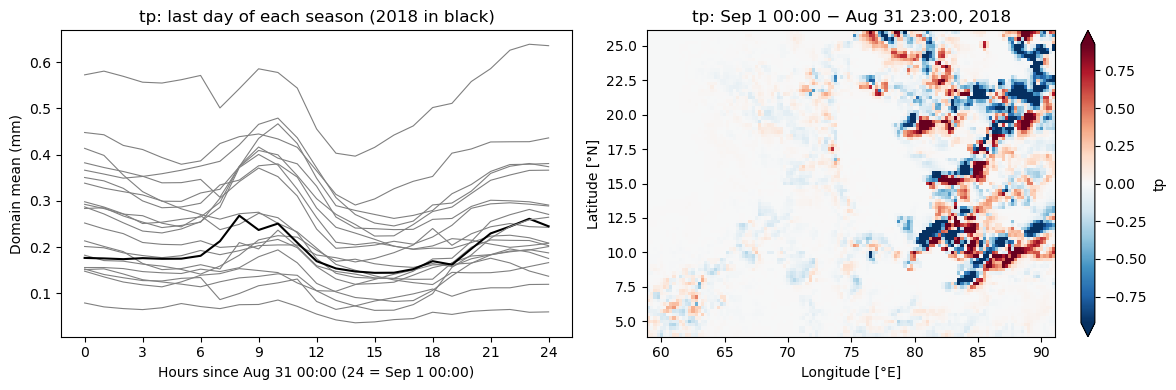

In [55]:
fig,axs = plt.subplots(1,2,figsize=(12,4))
for year in YEARS:
    window = combined[VARNAME].sel(time=slice(f'{year}-08-31 00:00',f'{year}-09-01 00:00'))
    mean   = window.mean([dim for dim in window.dims if dim!='time'])
    axs[0].plot(np.arange(window.sizes['time']),mean.values,color='gray' if year!=PLOTYEAR else 'k',lw=0.8 if year!=PLOTYEAR else 1.5)
axs[0].set_xticks(np.arange(0,25,3))
axs[0].set_xlabel('Hours since Aug 31 00:00 (24 = Sep 1 00:00)')
axs[0].set_ylabel(f'Domain mean ({UNITS})')
axs[0].set_title(f'{VARNAME}: last day of each season ({PLOTYEAR} in black)')
level = {'lev':float(combined.lev.max())} if 'lev' in combined.dims else {}
change = combined[VARNAME].sel(time=f'{PLOTYEAR}-09-01 00:00',**level)-combined[VARNAME].sel(time=f'{PLOTYEAR}-08-31 23:00',**level)
change.plot(ax=axs[1],cmap='RdBu_r',robust=True)
axs[1].set_title(f'{VARNAME}: Sep 1 00:00 − Aug 31 23:00, {PLOTYEAR}'+(f' ({level["lev"]:.0f} hPa)' if level else ''))
plt.tight_layout()
plt.show()

## 5. Save

Run only after inspecting the cells above. Writes the combined data to a temporary file, verifies it by reopening, renames the original to `<name>_old.nc`, and moves the new file to the original name.

In [56]:
if os.path.exists(BACKUPPATH):
    raise FileExistsError(f'{BACKUPPATH} already exists; this variable has been processed before')
if os.path.exists(TEMPPATH):
    raise FileExistsError(f'{TEMPPATH} already exists; remove it before saving again')
for variable in combined.variables.values():
    variable.encoding = {}
chunks = tuple(min(TIMECHUNKSIZE,size) if dim=='time' else size for dim,size in zip(combined[VARNAME].dims,combined[VARNAME].shape))
with ProgressBar():
    combined.to_netcdf(TEMPPATH,engine='h5netcdf',encoding={VARNAME:{'chunksizes':chunks}})
with xr.open_dataset(TEMPPATH,engine='h5netcdf') as check:
    problems = []
    if dict(check.sizes)!=dict(combined.sizes):
        problems.append(f'sizes {dict(check.sizes)} != {dict(combined.sizes)}')
    if not (pd.DatetimeIndex(check.time.values)==combinedtimes).all():
        problems.append('timestamps differ')
    if check[VARNAME].dtype!=combined[VARNAME].dtype:
        problems.append(f'dtype {check[VARNAME].dtype} != {combined[VARNAME].dtype}')
    if not check[VARNAME].sel(time=NEWTIMES).load().equals(new[VARNAME]):
        problems.append('new hours differ after reading back')
if problems:
    raise ValueError(f'{TEMPPATH} failed verification: {problems}; the original file is untouched')
old.close()
os.rename(FILEPATH,BACKUPPATH)
os.rename(TEMPPATH,FILEPATH)
with xr.open_dataset(FILEPATH,engine='h5netcdf') as check:
    finaltimes = pd.DatetimeIndex(check.time.values)
print(f'Saved {FILEPATH}: {len(finaltimes)} timestamps, {finaltimes[0]} → {finaltimes[-1]}')
print(f'Original kept as {BACKUPPATH}')

[########################################] | 100% Completed | 5.64 sms
Saved /global/cfs/cdirs/m4334/sferrett/monsoon-discovery/data/raw/ERA5_total_accumulated_precipitation.nc: 46389 timestamps, 2000-06-01 00:00:00 → 2020-09-01 00:00:00
Original kept as /global/cfs/cdirs/m4334/sferrett/monsoon-discovery/data/raw/ERA5_total_accumulated_precipitation_old.nc
